<a href="https://colab.research.google.com/github/Devadeth-cmyk/Case-Study-on-Preprocessing/blob/main/heart_disease_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries

In [74]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from statistics import mode

#scaling numerical data
from sklearn.preprocessing import MinMaxScaler

from sklearn.feature_selection import mutual_info_regression

#encoding non numerical columns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

# for train test split we have to import the method from scikit learn
from sklearn.model_selection import train_test_split

# for importing different classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# for importing different regression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# for evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score



#Read Dataset

In [75]:
filepath = "/content/drive/MyDrive/AI ML/Datasets/heart_disease.csv"
df_heart = pd.read_csv(filepath)
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


#EDA

In [76]:
df_heart.shape

(1025, 14)

In [77]:
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [78]:
df_heart.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [79]:
df_heart.value_counts()

age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target
38   1    2   138       175   0    1        173      0      0.0      2      4   2     1         8
40   1    0   152       223   0    1        181      0      0.0      2      0   3     0         4
              110       167   0    0        114      1      2.0      1      0   3     0         4
41   1    1   120       157   0    1        182      0      0.0      2      0   2     1         4
71   0    0   112       149   0    1        125      0      1.6      1      0   2     1         4
                                                                                               ..
41   0    1   105       198   0    1        168      0      0.0      2      1   2     1         3
40   1    3   140       199   0    1        178      1      1.4      2      0   3     1         3
34   0    1   118       210   0    1        192      0      0.7      2      0   2     1         3
77   1    0   125       304   0    0        162      1      0.0      2      3   2     0         3
39   1    2   140       321   0    0        182      0      0.0      2      0   2     1         3
Name: count, Length: 302, dtype: int64

In [80]:
#checking null values
df_heart.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [81]:
#checking duplicate values
df_heart.duplicated().sum()

np.int64(723)

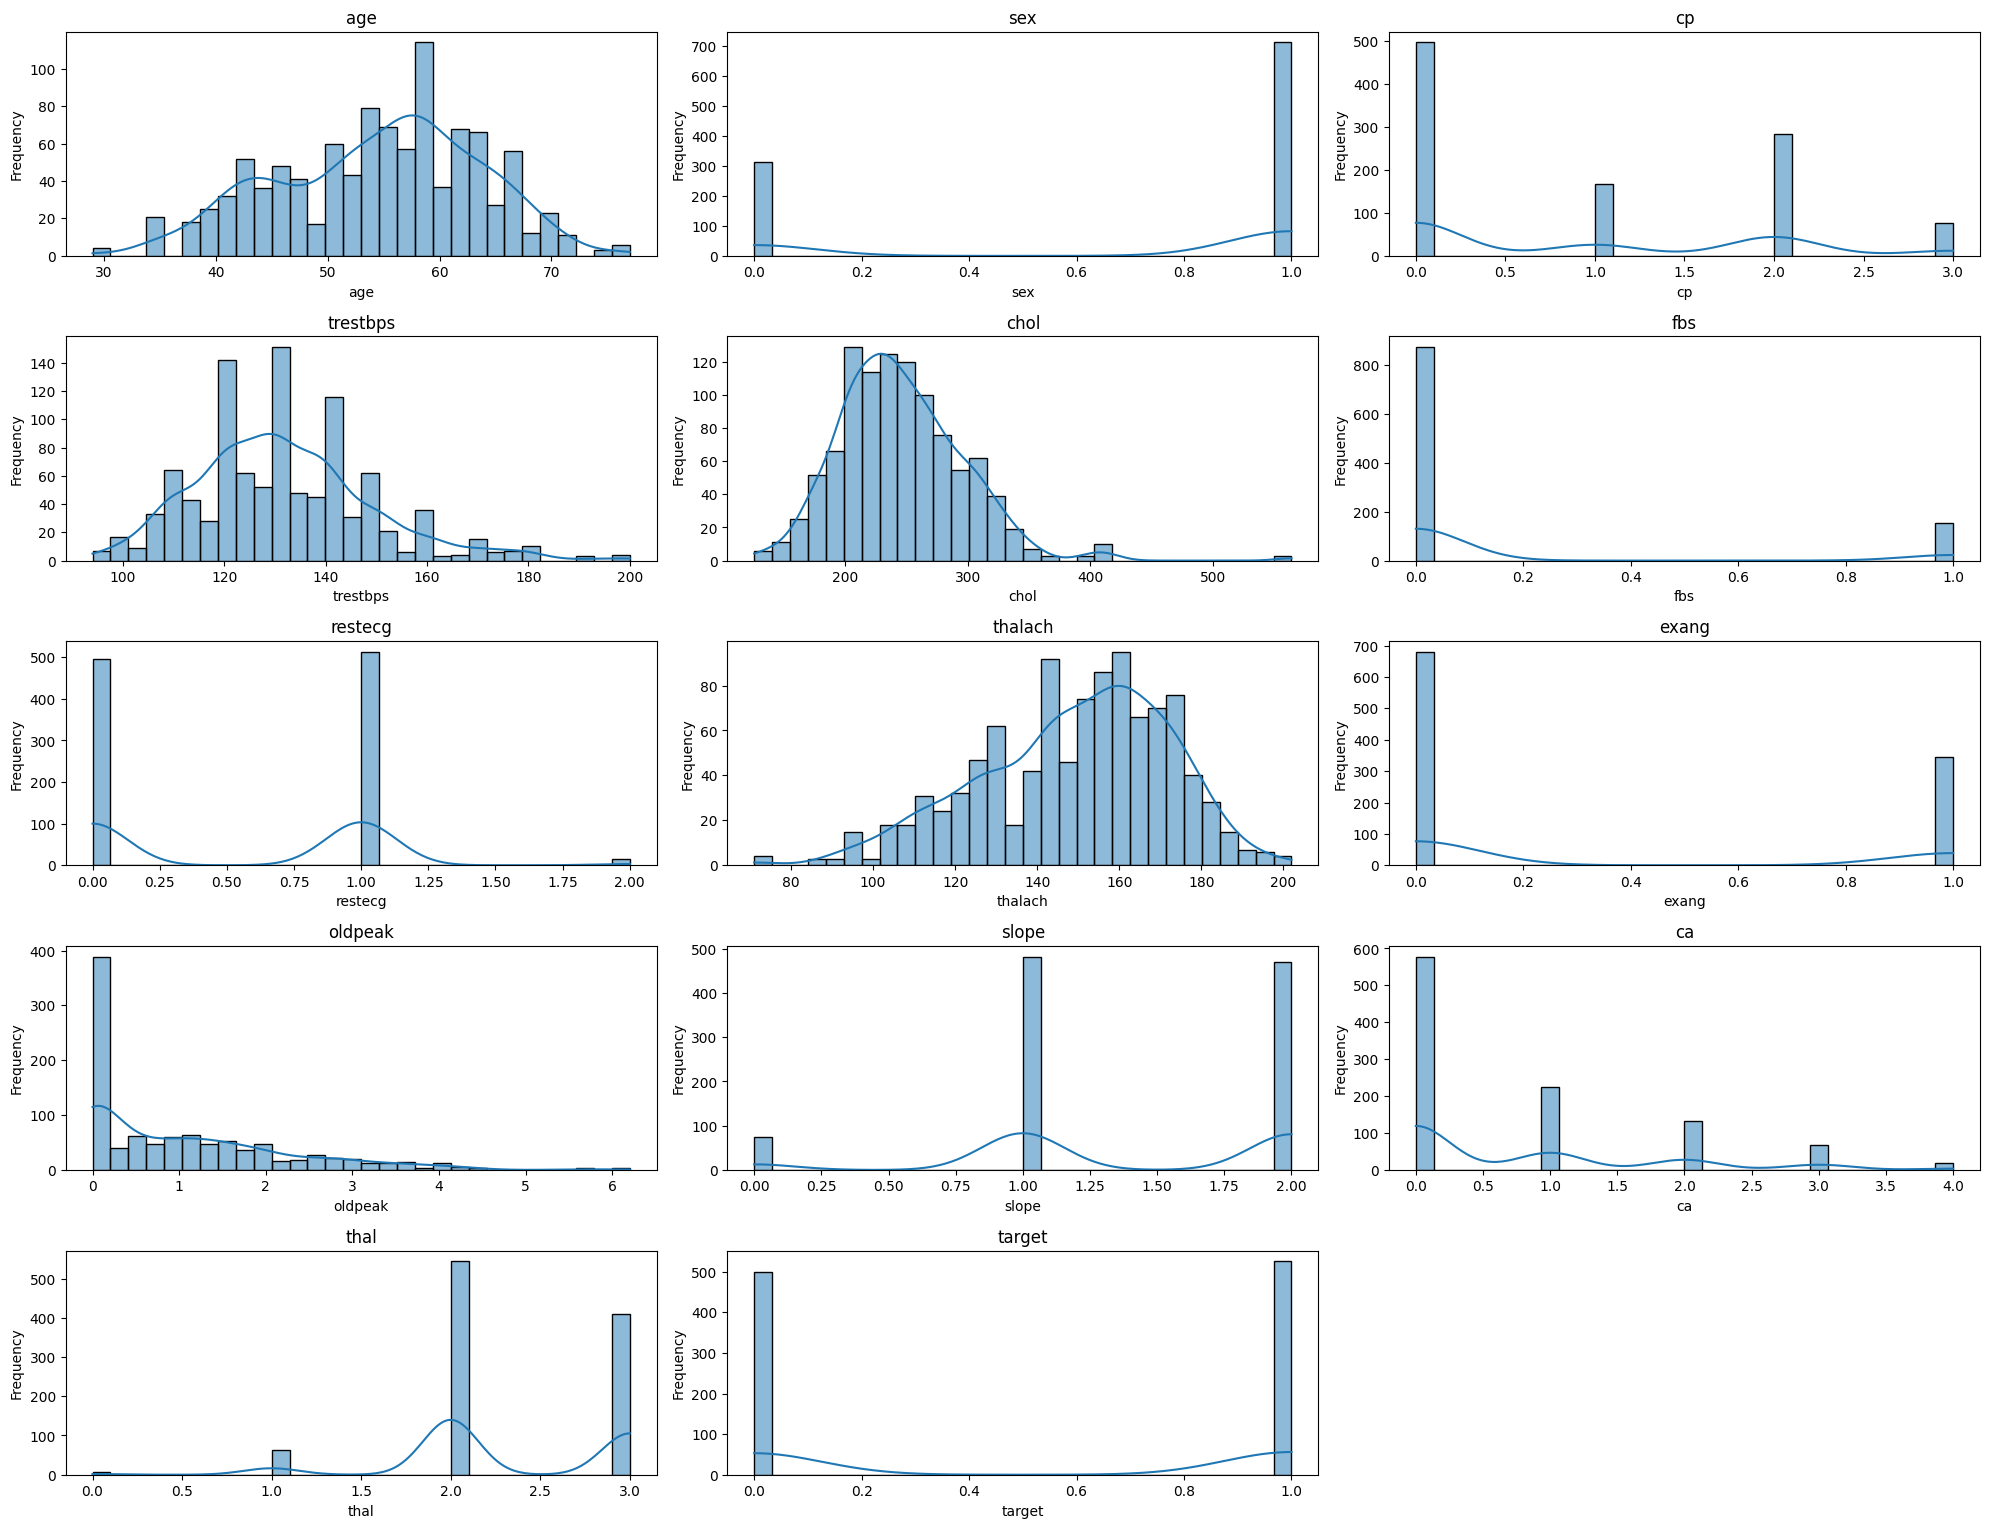

In [82]:
#plotting histogram of data

num_columns = df_heart.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(20, 18))
for i, col in enumerate(num_columns, 1):
    plt.subplot(6, 3, i)
    sns.histplot(df_heart[col], bins=30, kde=True)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#Data Preprocessing

##Duplicates removal

In [83]:
#before dropping duplicates
df_heart.shape

(1025, 14)

In [84]:
#dropping duplicate values
df_heart.drop_duplicates(inplace = True)

In [85]:
#after dropping duplicates
df_heart.shape

(302, 14)

##Correlation

In [86]:
#correlation can be figured out only using numerical data.
corr_mat = df_heart.corr()
corr_mat

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.094962,-0.063107,0.283121,0.207216,0.119492,-0.111590,-0.395235,0.093216,0.206040,-0.164124,0.302261,0.065317,-0.221476
sex,-0.094962,1.000000,-0.051740,-0.057647,-0.195571,0.046022,-0.060351,-0.046439,0.143460,0.098322,-0.032990,0.113060,0.211452,-0.283609
cp,-0.063107,-0.051740,1.000000,0.046486,-0.072682,0.096018,0.041561,0.293367,-0.392937,-0.146692,0.116854,-0.195356,-0.160370,0.432080
trestbps,0.283121,-0.057647,0.046486,1.000000,0.125256,0.178125,-0.115367,-0.048023,0.068526,0.194600,-0.122873,0.099248,0.062870,-0.146269
chol,0.207216,-0.195571,-0.072682,0.125256,1.000000,0.011428,-0.147602,-0.005308,0.064099,0.050086,0.000417,0.086878,0.096810,-0.081437
fbs,0.119492,0.046022,0.096018,0.178125,0.011428,1.000000,-0.083081,-0.007169,0.024729,0.004514,-0.058654,0.144935,-0.032752,-0.026826
restecg,-0.111590,-0.060351,0.041561,-0.115367,-0.147602,-0.083081,1.000000,0.041210,-0.068807,-0.056251,0.090402,-0.083112,-0.010473,0.134874
thalach,-0.395235,-0.046439,0.293367,-0.048023,-0.005308,-0.007169,0.041210,1.000000,-0.377411,-0.342201,0.384754,-0.228311,-0.094910,0.419955
exang,0.093216,0.143460,-0.392937,0.068526,0.064099,0.024729,-0.068807,-0.377411,1.000000,0.286766,-0.256106,0.125377,0.205826,-0.435601
oldpeak,0.206040,0.098322,-0.146692,0.194600,0.050086,0.004514,-0.056251,-0.342201,0.286766,1.000000,-0.576314,0.236560,0.209090,-0.429146


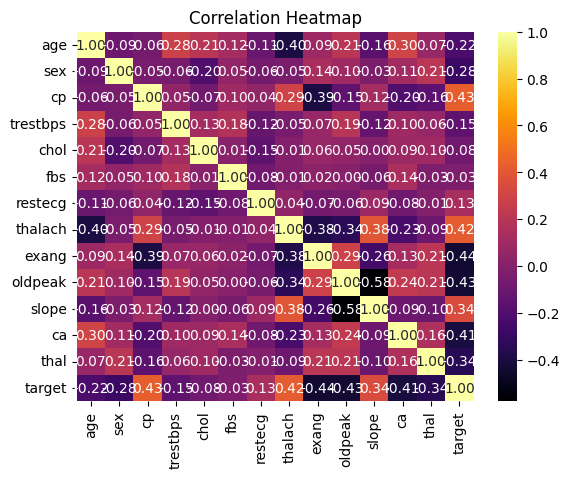

In [87]:
#visualization using heat map
sns.heatmap(corr_mat, annot = True, cmap = 'inferno', fmt = '0.2f' )
plt.title('Correlation Heatmap')
plt.show()


##Mutual Information


In [88]:
# # mutual information of each column
# mi = mutual_info_regression(X, y)
# # converting into a dataframe
# mi_X = pd.DataFrame({'Features' : X.columns, 'mutual Information':mi})
# mi_X


##Outlier handling

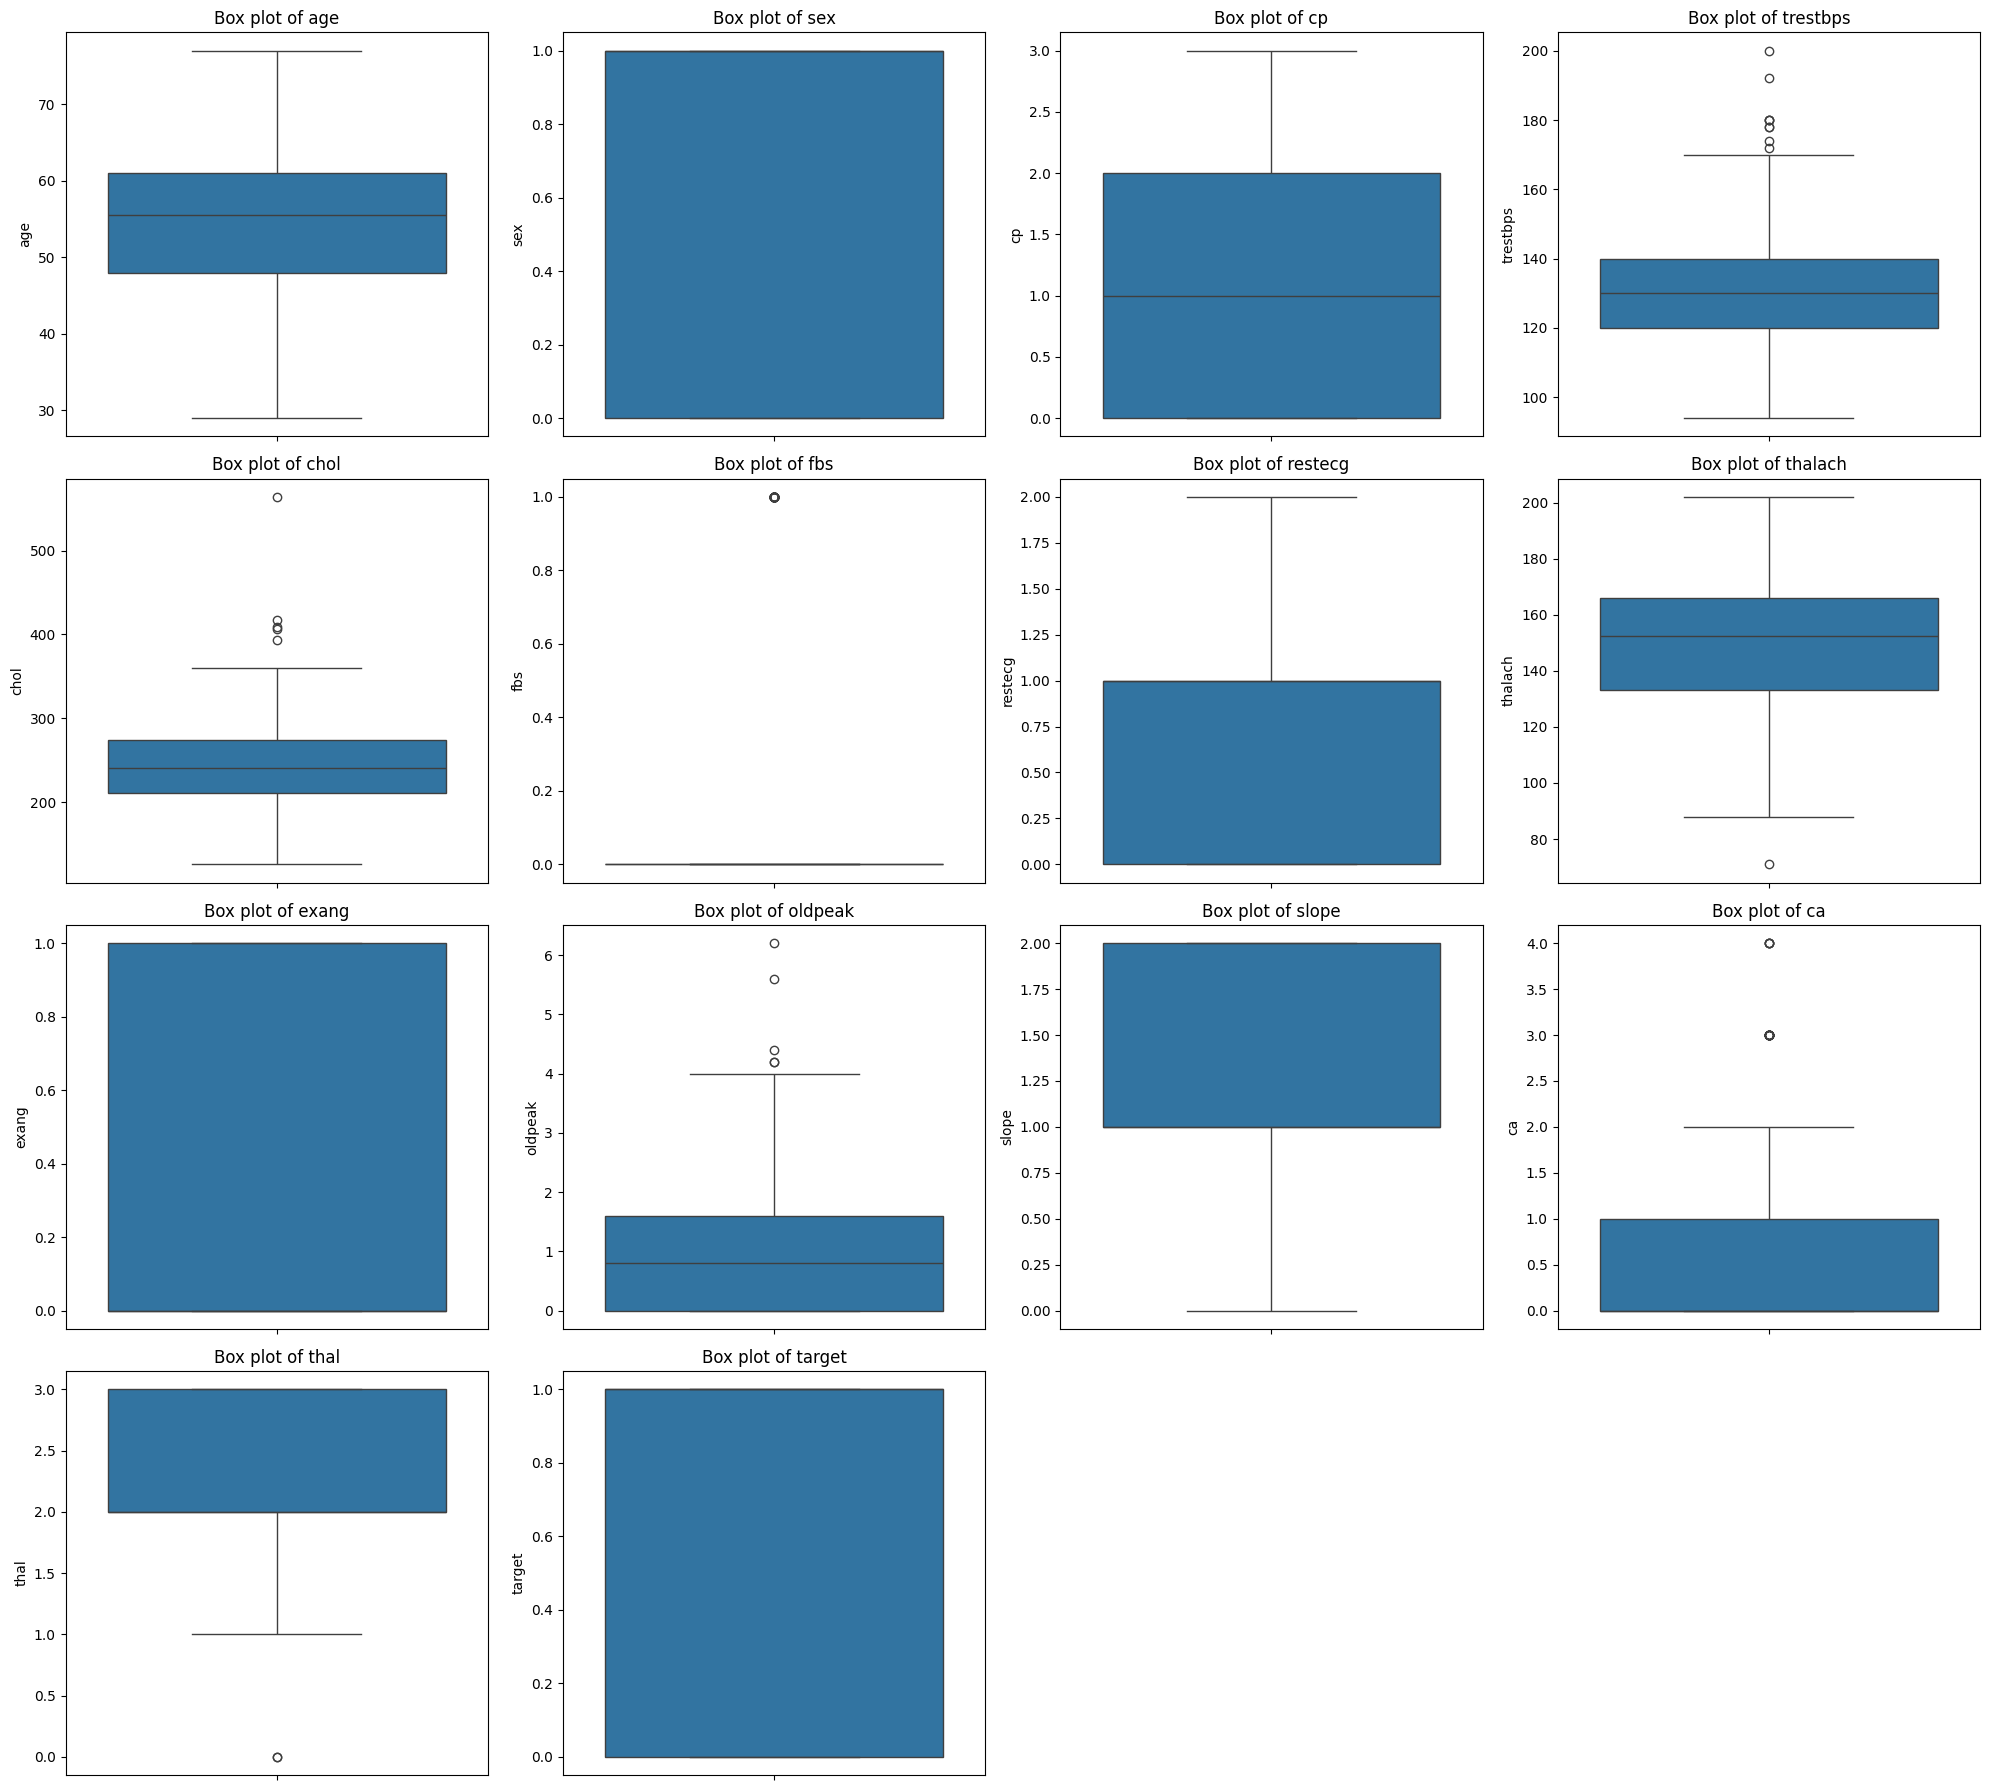

In [89]:
# Boxplots before handling outliers
plt.figure(figsize = (20,18))
for i, column in enumerate(df_heart.columns):
  plt.subplot(4,4,i+1)
  plt.title(f'Box plot of {column}')
  sns.boxplot(y = df_heart[column])
plt.tight_layout()
plt.show()



In [90]:
# #Handling Outliers
# def clipping(column):
#   Q1 = df_heart[column].quantile(0.25)
#   Q3 = df_heart[column].quantile(0.75)
#   IQR = Q3 - Q1

#   upper_bound = Q1 - (1.5 * IQR)
#   lower_bound = Q3 + (1.5 * IQR)

#   df_heart[column] = np.clip(df_heart[column], lower_bound, upper_bound)
#   return df_heart

# # Applying clipping to all columns

# for column in df_heart.columns:
#   outlier_cols = clipping(column)

In [91]:
# #Boxplot after outlier handlings

# plt.figure(figsize = (30,30))

# for i, column in enumerate(df_heart.columns):
#   plt.subplot(4,4,i+1)
#   plt.title(f'Box plot of {column}')
#   sns.boxplot(y = df_heart[column])
# plt.tight_layout()
# plt.show()

##Data Transform

###Encoding


In [92]:
#before encoding
df_heart.head(3)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0


In [93]:
#one hot encoding applied for 3 columns
OHE_obj = OneHotEncoder(sparse_output=False)
ohe_cols = ['restecg', 'cp', 'thal']

encoded_data = OHE_obj.fit_transform(df_heart[ohe_cols])
encoded_cols = OHE_obj.get_feature_names_out(ohe_cols)

encoded_X = pd.DataFrame(encoded_data, columns = encoded_cols, index = df_heart.index)
encoded_X.head(3)



,restecg_0,restecg_1,restecg_2,cp_0,cp_1,cp_2,cp_3,thal_0,thal_1,thal_2,thal_3
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [94]:
#concatenating the encode columns with 'X' and dropping the original columns
X = pd.concat([df_heart.drop(columns = ohe_cols), encoded_X], axis = 1)
#after encoding
X.head(10)


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,...,restecg_1,restecg_2,cp_0,cp_1,cp_2,cp_3,thal_0,thal_1,thal_2,thal_3
0,52,1,125,212,0,168,0,1.0,2,2,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,53,1,140,203,1,155,1,3.1,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,70,1,145,174,0,125,1,2.6,0,0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,61,1,148,203,0,161,0,0.0,2,1,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,62,0,138,294,1,106,0,1.9,1,3,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,58,0,100,248,0,122,0,1.0,1,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,58,1,114,318,0,140,0,4.4,0,3,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7,55,1,160,289,0,145,1,0.8,1,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8,46,1,120,249,0,144,0,0.8,2,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9,54,1,122,286,0,116,1,3.2,1,2,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [95]:
df_heart1 = df_heart    # for regression

In [96]:
#We use 'chol' column as target for regression models, so we do not do scaling to chol
min_max_scaler = MinMaxScaler()
reg_col = ['age', 'trestbps','oldpeak','thalach']
df_heart1[reg_col] = min_max_scaler.fit_transform(df_heart1[reg_col])

In [97]:
df_heart1.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.479167,1,0,0.292453,212,0,1,0.740458,0,0.161290,2,2,3,0
1,0.500000,1,0,0.433962,203,1,0,0.641221,1,0.500000,0,0,3,0
2,0.854167,1,0,0.481132,174,0,1,0.412214,1,0.419355,0,0,3,0
3,0.666667,1,0,0.509434,203,0,1,0.687023,0,0.000000,2,1,3,0
4,0.687500,0,0,0.415094,294,1,1,0.267176,0,0.306452,1,3,2,0


###Scaling

In [98]:
#before scaling
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.479167,1,0,0.292453,212,0,1,0.740458,0,0.161290,2,2,3,0
1,0.500000,1,0,0.433962,203,1,0,0.641221,1,0.500000,0,0,3,0
2,0.854167,1,0,0.481132,174,0,1,0.412214,1,0.419355,0,0,3,0
3,0.666667,1,0,0.509434,203,0,1,0.687023,0,0.000000,2,1,3,0
4,0.687500,0,0,0.415094,294,1,1,0.267176,0,0.306452,1,3,2,0


In [99]:
#we use minmax scaler because the columns are skewed
min_max_scaler = MinMaxScaler()
skewed_cols = ['age', 'trestbps','chol','oldpeak','thalach']
df_heart[skewed_cols] = min_max_scaler.fit_transform(df_heart[skewed_cols])

In [100]:
#after scaling
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.479167,1,0,0.292453,0.196347,0,1,0.740458,0,0.161290,2,2,3,0
1,0.500000,1,0,0.433962,0.175799,1,0,0.641221,1,0.500000,0,0,3,0
2,0.854167,1,0,0.481132,0.109589,0,1,0.412214,1,0.419355,0,0,3,0
3,0.666667,1,0,0.509434,0.175799,0,1,0.687023,0,0.000000,2,1,3,0
4,0.687500,0,0,0.415094,0.383562,1,1,0.267176,0,0.306452,1,3,2,0


#Model Building

In [101]:
#setting feature and target columns
y = df_heart['target']
X = df_heart.drop(columns=['target'])

In [102]:
y1 = df_heart1['chol']
X1 = df_heart1.drop(columns = ['chol'])

##Train Test Split

In [103]:
#split to train and test - Classifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [104]:
#split to train and test - Regressor
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size = 0.2, random_state = 42)

##Regression

###Linear Regressor

In [105]:
# create model object
lin_reg = LinearRegression()

# Train the model
lin_reg.fit(X1_train, y1_train)

# predictions using the model
y1_pred_lin = lin_reg.predict(X1_test)

# evaluate the model
mae_lin = mean_absolute_error(y1_test, y1_pred_lin)
mse_lin = mean_squared_error(y1_test, y1_pred_lin)
rmse_lin = root_mean_squared_error(y1_test, y1_pred_lin)
r2_lin = r2_score(y1_test, y1_pred_lin)
print('Evaluation of Linear Regression Model')
print("*****************************")
print("MAE:", mae_lin)
print("MSE:", mse_lin)
print("RMSE:", rmse_lin)
print("R2_Score:", r2_lin)

Evaluation of Linear Regression Model
*****************************
MAE: 0.07793224809924933
MSE: 0.010741629211269525
RMSE: 0.10364183137743913
R2_Score: -0.12339570807080769


###Random Forest Regressor

In [106]:
# create model object
rf_reg = RandomForestRegressor()

# Train the model
rf_reg.fit(X1_train, y1_train)

# predictions using the model
y1_pred_rf = rf_reg.predict(X1_test)

# evaluate the model
mae_rf = mean_absolute_error(y1_test, y1_pred_rf)
mse_rf = mean_squared_error(y1_test, y1_pred_rf)
rmse_rf = root_mean_squared_error(y1_test, y1_pred_rf)
r2_rf = r2_score(y1_test, y1_pred_rf)
print('Evaluation of RandomForest Model')
print("*****************************")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2_Score:", r2_rf)

Evaluation of RandomForest Model
*****************************
MAE: 0.07872445542331015
MSE: 0.010998601408042942
RMSE: 0.10487421707952313
R2_Score: -0.15027072463216085


###SVM Regressor

In [107]:
# create model object
svm_reg = SVR()

# Train the model
svm_reg.fit(X1_train, y1_train)

# predictions using the model
y1_pred_svm = svm_reg.predict(X1_test)

# evaluate the model
mae_svm = mean_absolute_error(y1_test, y1_pred_svm)
mse_svm = mean_squared_error(y1_test, y1_pred_svm)
rmse_svm = root_mean_squared_error(y1_test, y1_pred_svm)
r2_svm = r2_score(y1_test, y1_pred_svm)
print('Evaluation of SVM Model')
print("*****************************")
print("MAE:", mae_svm)
print("MSE:", mse_svm)
print("RMSE:", rmse_svm)
print("R2_Score:", r2_svm)

Evaluation of SVM Model
*****************************
MAE: 0.09333543699412826
MSE: 0.01426200413453849
RMSE: 0.1194236330653966
R2_Score: -0.4915683569136222


##Classification

###Logistic Regression

In [108]:
# build the model
log_reg= LogisticRegression()
# Train the model
log_reg.fit(X_train, y_train)
# make predictions using the LogisticRegression model
y_pred_log = log_reg.predict(X_test)

# evaluate the model
acc_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
print('Evaluation of Logistic Regression Model')
print("*****************************")
print("Accuracy : ", acc_log)
print("Precision : ", precision_log)
print("Recall : ", recall_log)
print("F1_Score : ", f1_log)

Evaluation of Logistic Regression Model
*****************************
Accuracy :  0.7868852459016393
Precision :  0.7352941176470589
Recall :  0.8620689655172413
F1_Score :  0.7936507936507936


###Knn Classifier

In [109]:
# build the model
knn_classifier= KNeighborsClassifier()
# Train the model
knn_classifier.fit(X_train, y_train)
# make predictions using the LogisticRegression model
y_pred_knn = knn_classifier.predict(X_test)

# evaluate the model
acc_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
print('Evaluation of KNN Classifier Model')
print("*****************************")
print("Accuracy : ", acc_knn)
print("Precision : ", precision_knn)
print("Recall : ", recall_knn)
print("F1_Score : ", f1_knn)

Evaluation of KNN Classifier Model
*****************************
Accuracy :  0.8360655737704918
Precision :  0.7714285714285715
Recall :  0.9310344827586207
F1_Score :  0.84375


###Random Forest CLassifier

In [110]:
# build the model
rf_classifier = RandomForestClassifier()
# Train the model
rf_classifier.fit(X_train, y_train)
# make predictions using the LogisticRegression model
y_pred_rfc = rf_classifier.predict(X_test)

# evaluate the model
acc_rfc = accuracy_score(y_test, y_pred_rfc)
precision_rfc = precision_score(y_test, y_pred_rfc)
recall_rfc = recall_score(y_test, y_pred_rfc)
f1_rfc = f1_score(y_test, y_pred_rfc)
print('Evaluation of Random Forest Classifier Model')
print("*****************************")
print("Accuracy : ", acc_rfc)
print("Precision : ", precision_rfc)
print("Recall : ", recall_rfc)
print("F1_Score : ", f1_rfc)

Evaluation of Random Forest Classifier Model
*****************************
Accuracy :  0.819672131147541
Precision :  0.78125
Recall :  0.8620689655172413
F1_Score :  0.819672131147541
